# 16 - Employee Intelligence Table

Day 3, step 16. Everything from the last three days lands here: one row per employee
carrying attrition risk, engagement, role, skill gaps and a recommendation.

This table is the actual business output of the project. The dashboard is a view onto
it, and the API mostly serves slices of it.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from app.utils.config import PROCESSED_FILES
from pipelines import build_intelligence

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 240)
pd.set_option("display.max_colwidth", 42)

intelligence = build_intelligence.build()
print(intelligence.shape)

2026-09-02 14:07:39 | INFO    | hr_ai.intelligence | spine: 1470 employees


2026-09-02 14:07:39 | INFO    | hr_ai.model_loader | Model v1 loaded from attrition_pipeline.joblib


2026-09-02 14:07:39 | INFO    | hr_ai.predictor | Scored 1470 employees with model v1 (threshold 0.58)


2026-09-02 14:07:39 | INFO    | hr_ai.intelligence | skill gaps: 15509 rows across 52 distinct skills


2026-09-02 14:07:40 | INFO    | hr_ai.intelligence | recommendations: 4409 rows, 1470 employees covered


2026-09-02 14:07:40 | INFO    | hr_ai.intelligence | intelligence table: (1470, 23) -> employee_intelligence.csv


(1470, 23)


## The shape the build notes asked for

```
Employee_ID | Dept | Attrition_Prob | Risk | Engagement | Role | Skill_Gap | Recommendation
```

In [2]:
intelligence[["EmployeeID", "Department", "AttritionProbability", "RiskLevel",
              "EngagementScore", "JobRole", "TopMissingSkill", "Recommendation"]].head(10)

,EmployeeID,Department,AttritionProbability,RiskLevel,EngagementScore,JobRole,TopMissingSkill,Recommendation
0,1,Sales,0.8875,HIGH,53.3,Sales Executive,Microsoft PowerPoint,Learn Microsoft PowerPoint
1,2,Research & Development,0.0926,LOW,51.7,Research Scientist,R,Learn R
2,4,Research & Development,0.8391,HIGH,61.7,Laboratory Technician,Microsoft Excel,Learn Microsoft Excel
3,5,Research & Development,0.3370,LOW,73.4,Research Scientist,R,Learn R
4,7,Research & Development,0.6407,HIGH,46.7,Laboratory Technician,Reading Comprehension,Learn Reading Comprehension
5,8,Research & Development,0.1418,LOW,78.3,Laboratory Technician,Microsoft Excel,Learn Microsoft Excel
6,10,Research & Development,0.5555,MEDIUM,43.3,Laboratory Technician,Microsoft Office,Learn Microsoft Office
7,11,Research & Development,0.4610,MEDIUM,70.0,Laboratory Technician,Microsoft Excel,Learn Microsoft Excel
8,12,Research & Development,0.2085,LOW,61.7,Manufacturing Director,Microsoft PowerPoint,Learn Microsoft PowerPoint
9,13,Research & Development,0.1900,LOW,58.4,Healthcare Representative,Microsoft Office,Learn Microsoft Office


## The join discipline that keeps this correct

Notebook 04 established the rule and this is where it pays off. The employee table is
the spine; every other source is aggregated to one row per employee *before* joining.

Skill gaps arrive at ~15,500 rows and recommendations at ~4,400. Joining either
directly would multiply the spine and inflate every count on the dashboard - and the
result would still look plausible, which is what makes it dangerous.

In [3]:
employees = pd.read_csv(PROCESSED_FILES["attrition"])
gaps = pd.read_csv(PROCESSED_FILES["skill_gaps"])
recommendations = pd.read_csv(PROCESSED_FILES["recommendations"])

print(f"employees (spine)      {len(employees):>7,}")
print(f"skill gap rows         {len(gaps):>7,}")
print(f"recommendation rows    {len(recommendations):>7,}")
print(f"intelligence table     {len(intelligence):>7,}  <- must equal the spine")

assert len(intelligence) == len(employees)
assert not intelligence["EmployeeID"].duplicated().any()
print("\nOne row per employee, no duplicates.")

employees (spine)        1,470
skill gap rows          15,509
recommendation rows      4,409
intelligence table       1,470  <- must equal the spine

One row per employee, no duplicates.


`build_intelligence.build()` raises rather than writing a bad table if either check
fails, so this cannot silently regress later.

## Completeness

In [4]:
pd.DataFrame({
    "non_null": intelligence.notna().sum(),
    "null": intelligence.isna().sum(),
    "dtype": intelligence.dtypes.astype(str),
})

,non_null,null,dtype
EmployeeID,1470,0,int64
Department,1470,0,object
JobRole,1470,0,object
Age,1470,0,int64
MonthlyIncome,1470,0,int64
YearsAtCompany,1470,0,int64
OverTime,1470,0,object
Attrition,1470,0,object
AttritionProbability,1470,0,float64
RiskLevel,1470,0,object


## The dashboard KPIs

In [5]:
kpis = {
    "Employees": len(intelligence),
    "High risk": int((intelligence["RiskLevel"] == "HIGH").sum()),
    "Medium risk": int((intelligence["RiskLevel"] == "MEDIUM").sum()),
    "Avg engagement": round(intelligence["EngagementScore"].mean(), 1),
    "Employees with skill gaps": int((intelligence["SkillGapCount"] > 0).sum()),
    "Avg skill gaps": round(intelligence["SkillGapCount"].mean(), 1),
}
pd.Series(kpis).to_frame("value")

,value
Employees,1470.0
High risk,351.0
Medium risk,285.0
Avg engagement,57.7
Employees with skill gaps,1470.0
Avg skill gaps,10.6


> **These risk counts are in-sample.** Every employee here was part of the data the
> model was trained on, so the probabilities are optimistic in the way any model is
> about data it has already seen. The honest performance estimate is the held-out test
> result in notebook 07 (ROC-AUC 0.80), not anything computed from this table. In
> production the model would score employees it had never seen.

## Risk distribution

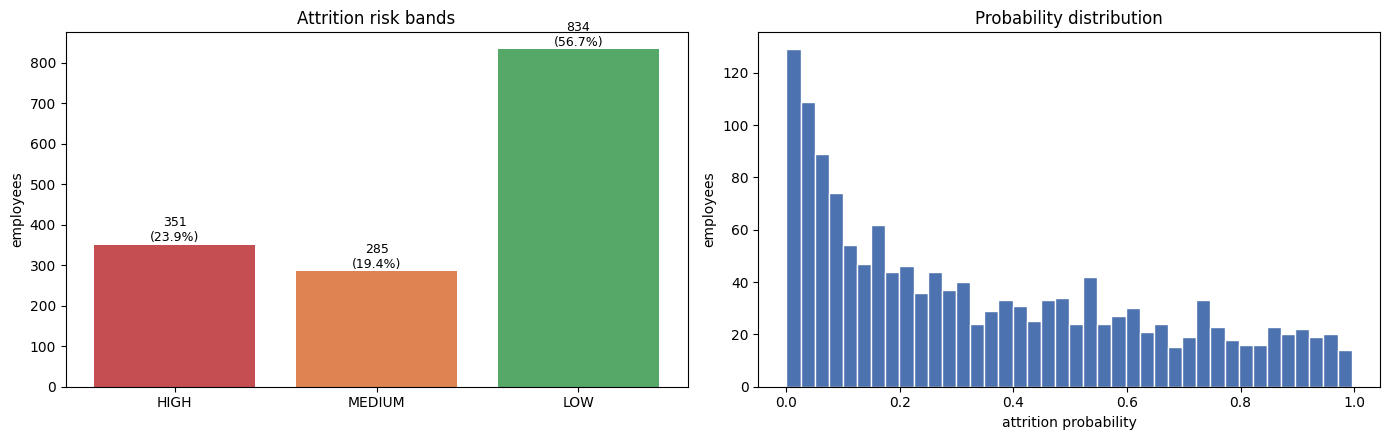

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))
order = ["HIGH", "MEDIUM", "LOW"]
counts = intelligence["RiskLevel"].value_counts().reindex(order)
ax1.bar(order, counts.values, color=["#C44E52", "#DD8452", "#55A868"])
for i, v in enumerate(counts.values):
    ax1.text(i, v + 8, f"{v}\n({v / len(intelligence) * 100:.1f}%)", ha="center", fontsize=9)
ax1.set(ylabel="employees", title="Attrition risk bands")

ax2.hist(intelligence["AttritionProbability"], bins=40, color="#4C72B0", edgecolor="white")
ax2.set(xlabel="attrition probability", ylabel="employees", title="Probability distribution")
plt.tight_layout()
plt.show()

## Attrition risk by department - the dashboard's main chart

In [7]:
by_department = (intelligence.groupby("Department")
                 .agg(Headcount=("EmployeeID", "count"),
                      HighRisk=("RiskLevel", lambda s: (s == "HIGH").sum()),
                      AvgProbability=("AttritionProbability", "mean"),
                      AvgEngagement=("EngagementScore", "mean"))
                 .round(3))
by_department["HighRisk%"] = (by_department["HighRisk"] / by_department["Headcount"] * 100).round(1)
by_department.sort_values("HighRisk%", ascending=False)

,Headcount,HighRisk,AvgProbability,AvgEngagement,HighRisk%
Department,,,,,
Sales,446,156,0.442,57.626,35.0
Human Resources,63,14,0.383,57.708,22.2
Research & Development,961,181,0.304,57.736,18.8


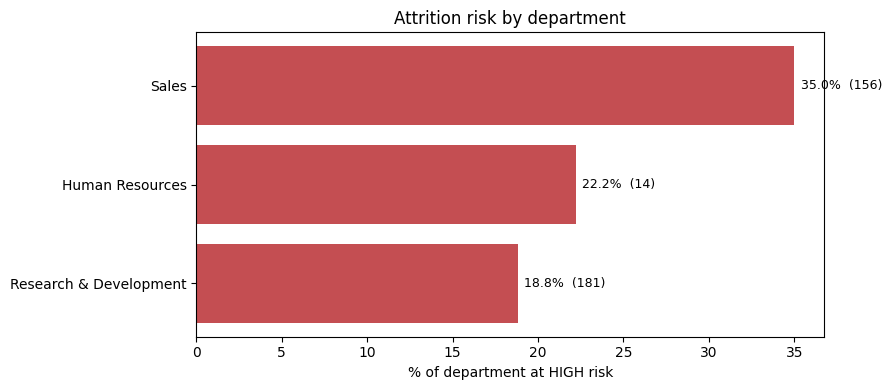

In [8]:
plot_data = by_department.sort_values("HighRisk%")
fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(plot_data.index, plot_data["HighRisk%"], color="#C44E52")
for i, (pct, n) in enumerate(zip(plot_data["HighRisk%"], plot_data["HighRisk"])):
    ax.text(pct + 0.4, i, f"{pct}%  ({n})", va="center", fontsize=9)
ax.set(xlabel="% of department at HIGH risk", title="Attrition risk by department")
plt.tight_layout()
plt.show()

## Where risk and skill gaps overlap

The cross-tabulation is the argument for building all three subsystems rather than
just the model: it identifies employees who are both likely to leave *and* under-
skilled, where targeted development is a retention lever rather than only a
capability one.

In [9]:
intelligence["GapBand"] = pd.cut(intelligence["SkillGapCount"],
                                 bins=[-1, 5, 9, 100],
                                 labels=["few (0-5)", "some (6-9)", "many (10+)"])
crosstab = pd.crosstab(intelligence["RiskLevel"], intelligence["GapBand"]).reindex(order)
crosstab

GapBand,few (0-5),some (6-9),many (10+)
RiskLevel,,,
HIGH,4,84,263
MEDIUM,9,68,208
LOW,21,281,532


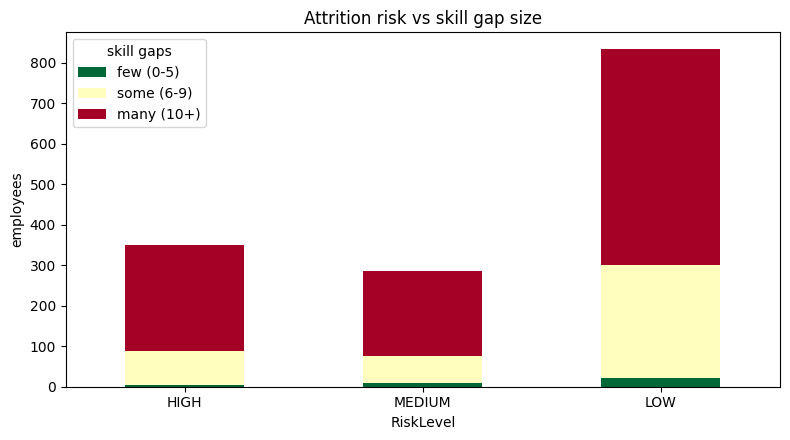

In [10]:
fig, ax = plt.subplots(figsize=(8, 4.5))
crosstab.plot(kind="bar", stacked=True, ax=ax, colormap="RdYlGn_r")
ax.set(ylabel="employees", title="Attrition risk vs skill gap size")
plt.xticks(rotation=0)
plt.legend(title="skill gaps")
plt.tight_layout()
plt.show()

## The priority list

High attrition risk, large skill gap, low engagement - the employees to act on first.

In [11]:
priority = (intelligence[intelligence["RiskLevel"] == "HIGH"]
            .sort_values(["SkillGapScore", "EngagementScore"], ascending=[False, True]))

priority.head(15)[["EmployeeID", "Department", "JobRole", "AttritionProbability",
                   "EngagementScore", "SkillGapCount", "TopMissingSkill", "Recommendation"]]

,EmployeeID,Department,JobRole,AttritionProbability,EngagementScore,SkillGapCount,TopMissingSkill,Recommendation
200,274,Research & Development,Manufacturing Director,0.8478,38.3,16,SAP,Learn SAP
127,167,Sales,Sales Representative,0.9851,71.7,17,Microsoft Excel,Learn Microsoft Excel
385,514,Research & Development,Research Scientist,0.9475,76.7,15,Microsoft Excel,Learn Microsoft Excel
1349,1893,Research & Development,Research Scientist,0.7731,46.7,15,Microsoft Excel,Learn Microsoft Excel
1339,1878,Research & Development,Research Scientist,0.8961,56.7,15,R,Learn R
437,585,Sales,Sales Representative,0.6577,56.7,16,Microsoft Excel,Learn Microsoft Excel
1359,1915,Sales,Sales Executive,0.5976,70.0,15,Microsoft PowerPoint,Learn Microsoft PowerPoint
691,964,Research & Development,Research Scientist,0.6572,66.7,15,Microsoft Office,Learn Microsoft Office
397,527,Sales,Sales Executive,0.8193,58.3,15,Microsoft PowerPoint,Learn Microsoft PowerPoint
1068,1504,Research & Development,Laboratory Technician,0.9727,33.3,16,Microsoft Excel,Learn Microsoft Excel


## A single employee, end to end

In [12]:
employee = priority.iloc[0]
print(f"=== Employee {int(employee['EmployeeID'])} ===")
print(f"  Role              : {employee['JobRole']} ({employee['Department']})")
print(f"  Age / tenure      : {int(employee['Age'])} / {int(employee['YearsAtCompany'])} years")
print(f"  Overtime          : {employee['OverTime']}")
print(f"  Attrition risk    : {employee['AttritionProbability']:.1%} ({employee['RiskLevel']})")
print(f"  Engagement        : {employee['EngagementScore']} ({employee['EngagementBand']})")
print(f"  Skill gaps ({int(employee['SkillGapCount'])})    : {employee['SkillGaps']}")
print(f"  Recommendation    : {employee['Recommendation']}")
print(f"  Course            : {employee['CourseTitle']} ({employee['Provider']}, "
      f"{employee['DurationHours']:.0f}h)")

=== Employee 274 ===
  Role              : Manufacturing Director (Research & Development)
  Age / tenure      : 27 / 2 years
  Overtime          : No
  Attrition risk    : 84.8% (HIGH)
  Engagement        : 38.3 (Low)
  Skill gaps (16)    : SAP, Microsoft PowerPoint, Microsoft Excel, Microsoft Office, Microsoft Outlook
  Recommendation    : Learn SAP
  Course            : Enterprise Resource Planning Essentials (SAP, 24h)


## Day 3 summary

| Step | Output |
|---|---|
| 10 Engagement | department and role breakdowns; disengaged high performers identified |
| 11 Role intelligence | nine job roles mapped to O*NET occupations, mapping documented |
| 12 Employee skills | confirmed absent from source data; controlled table built and validated |
| 13 Skill gap engine | 15,509 employee/skill gaps, importance-weighted |
| 14 Organisation gaps | severity per the notes, plus a proportional rule that discriminates |
| 15 Recommendations | tag-based matching with prioritisation by importance x severity x risk |
| 16 Intelligence table | 1,470 rows x 23 columns, one per employee |

Day 4 turns this into a service.

In [13]:
print(f"written: {PROCESSED_FILES['intelligence']}")
print(f"columns: {list(intelligence.columns)}")

written: D:\BE\SEM5\AGAI\HR_AI_Project\data\processed\employee_intelligence.csv
columns: ['EmployeeID', 'Department', 'JobRole', 'Age', 'MonthlyIncome', 'YearsAtCompany', 'OverTime', 'Attrition', 'AttritionProbability', 'RiskLevel', 'ModelVersion', 'EngagementScore', 'PerformanceRating', 'SkillGapCount', 'SkillGapScore', 'SkillGaps', 'TopMissingSkill', 'Recommendation', 'CourseTitle', 'Provider', 'DurationHours', 'Priority', 'EngagementBand', 'GapBand']
